# Getting started, on real materials

Every other tutorial builds its structures in code. This one does not: it loads
published structures — LiFePO₄ as it is actually reported, Li₁₀GeP₂S₁₂ as the
solid electrolyte people actually study — and runs a screen on them.

It executes end to end with no network, no API key and no downloaded model.

In [1]:
import matverse as mv

mv.datasets.available()

{'battery_cathodes': {'structures': ['LiFePO4', 'NaFePO4', 'Li3V2(PO4)3'],
  'description': 'Olivine and NASICON cathode materials. Li and Na analogues of the same framework sit side by side, so an intercalation comparison has something to compare.',
  'use_for': 'mv.neb migration barriers, mv.thermo.hull stability'},
 'solid_electrolytes': {'structures': ['Li10GeP2S12', 'Li2O', 'Li2O2'],
  'description': 'A superionic conductor and two simple lithium oxides. Li10GeP2S12 is the canonical fast-ion conductor and is 58 atoms, so it is also a realistic cost test.',
  'use_for': 'mv.md.conductivity, mv.neb.barrier'},
 'oxides': {'structures': ['SrTiO3', 'TiO2', 'VO2', 'BaNiO3', 'SiO2'],
  'description': 'Perovskite, rutile, and a metal-insulator transition compound. Spans wide-gap insulator to correlated metal.',
  'use_for': 'mv.prop.xrd, mv.thermo.hull, band gap screening'},
 'semiconductors': {'structures': ['Si', 'SiO2', 'TlBiSe2', 'Sn'],
  'description': 'Silicon and its oxide, a topol

Each bundled set is a coherent scenario rather than a grab-bag, and says what it
is *for*. Take the cathodes.

In [2]:
md = mv.datasets.load("battery_cathodes")
md

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 3 × 6
    obs: 'name', 'spacegroup', 'dataset', 'source'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is', 'dataset'
    obsm: 'structures'

`X` is already the composition matrix and `var` is already the periodic table.
Nobody asked for either — composition is intrinsic to a material rather than
derived from it, so it is built at construction.

In [3]:
import pandas as pd

pd.DataFrame(md.X.toarray(), index=md.obs["name"], columns=md.var_names)

element,Li,O,Na,P,V,Fe
name,,,,,,
LiFePO4,1.0,4.0,0.0,1.0,0.0,1.0
NaFePO4,0.0,4.0,1.0,1.0,0.0,1.0
Li3V2(PO4)3,3.0,12.0,0.0,3.0,2.0,0.0


Counts come from the **reduced** formula, so a supercell and its primitive cell
land on the same point in chemical space. Cell size lives in `obs['nsites']`.

`var` carries the periodic table restricted to the elements present:

In [4]:
md.var[["Z", "electronegativity", "period", "is_transition_metal"]]

,Z,electronegativity,period,is_transition_metal
element,,,,
Li,3.0,0.98,2.0,False
O,8.0,3.44,2.0,False
Na,11.0,0.93,3.0,False
P,15.0,2.19,3.0,False
V,23.0,1.63,4.0,True
Fe,26.0,1.83,4.0,True


## What are these?

In [5]:
mv.pp.describe(md)
mv.pp.qc(md)

md.obs[["name", "spacegroup", "formula", "nsites", "density", "is_valid"]]

,name,spacegroup,formula,nsites,density,is_valid
0,LiFePO4,P2_1/c,LiFePO4,28,3.497400,True
1,NaFePO4,Pnma,NaFePO4,28,3.520424,True
2,Li3V2(PO4)3,C2,Li3V2(PO4)3,40,2.875413,True


## A diffraction pattern for each

`mv.prop.xrd` needs no calculator, so it runs on anything — which makes it the
first real property available for a set like this.

In [6]:
mv.prop.xrd(md, two_theta=(10, 60), step=0.02)

md.obsm["xrd_calc"].shape, mv.grid_of(md, "xrd").shape

((3, 2501), (2501,))

The patterns are a `materials × 2θ` block on a shared grid, which is what makes
them comparable. A peak list would not be: no two materials share peak
positions.

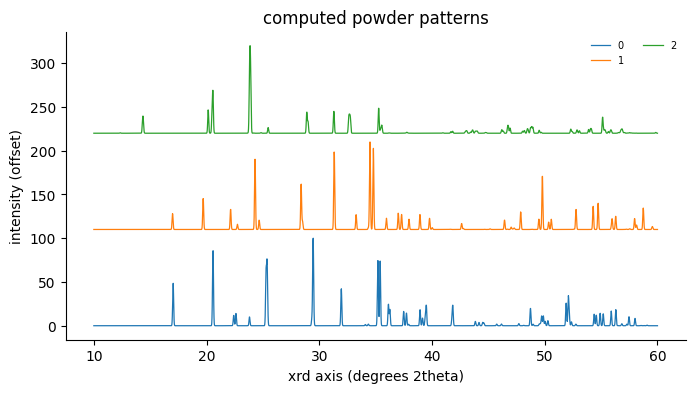

In [7]:
import matplotlib.pyplot as plt

ax = mv.pl.spectra(md, "xrd", rows=[0, 1, 2], offset=110)
ax.set_title("computed powder patterns")
ax.figure.set_size_inches(8, 4)

LiFePO₄ and NaFePO₄ are the same framework with a different alkali, and the
patterns show it — the same families of reflections, shifted.

## Phase identification

Feed one of them back as if it were measured, and ask which candidate it is.

In [8]:
measured = md.obsm["xrd_calc"][1]              # pretend we measured row 1
mv.exp.match_xrd(md, measured, mv.grid_of(md, "xrd"))

md.obs[["name", "xrd_match", "xrd_match_rank"]].sort_values("xrd_match_rank")

,name,xrd_match,xrd_match_rank
1,NaFePO4,1.000000,1.0
2,Li3V2(PO4)3,0.062813,2.0
0,LiFePO4,0.046845,3.0


```{warning}
`match_xrd` scores against the candidates in this object and nothing else, and
records that in `uns['xrd_match']['scored_against']`. A high score means "the
best of what you gave it", not "identified" — the true phase can be absent from
your library entirely.
```

## Running a calculator

The cathodes contain Fe, P and V, which the only calculator that ships working —
ASE's effective-medium theory — is not parameterised for. That is a real
constraint rather than a tutorial convenience, so the screen switches to the
metals EMT *can* run.

In [9]:
mv.calc.available()["emt"]

{'kind': 'classical',
 'method': 'EMT',
 'reference': None,
 'surrogate': True,
 'license': 'LGPL-2.1',
 'uncertainty': None,
 'note': 'ASE effective-medium theory. Parameterised only for Al Cu Ag Au Ni Pd Pt H C N O — enough to exercise a pipeline, not enough to screen with.'}

In [10]:
metals = mv.datasets.metals()
metals.obs[["name", "lattice_parameter"]]

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,name,lattice_parameter
0,Al,4.0495
1,Cu,3.6149
2,Ni,3.5240
3,Ag,4.0853
4,Au,4.0782
5,Pd,3.8907
6,Pt,3.9242


Published room-temperature lattice parameters. Relax them:

In [11]:
mv.pp.describe(metals)
mv.calc.relax(metals, level="emt", fmax=0.02)

metals.obs[["name", "energy_per_atom_emt", "relax_converged_emt"]]

,name,energy_per_atom_emt,relax_converged_emt
0,Al,-0.001562,True
1,Cu,-0.004953,True
2,Ni,-0.007592,True
3,Ag,0.000958,True
4,Au,0.002212,True
5,Pd,0.000420,True
6,Pt,-0.000106,True


The relaxed geometry becomes its own variant rather than replacing the input, so
"which structure was this energy computed on" stays answerable:

In [12]:
mv.variants(metals)

['input', 'relaxed_emt']

## Properties that need the calculator

Elastic constants by finite strain, and phonons by frozen displacement.

In [13]:
mv.prop.elastic(metals, level="emt", source="relaxed_emt")
mv.prop.phonon(metals, level="emt", source="relaxed_emt", supercell=(1, 1, 1))
mv.prop.thermal_conductivity(metals, level="emt")

metals.obs[["name", "bulk_modulus_emt", "debye_temperature_emt",
            "thermal_conductivity_emt", "dynamically_stable_emt"]].round(1)

,name,bulk_modulus_emt,debye_temperature_emt,thermal_conductivity_emt,dynamically_stable_emt
0,Al,35.4,392.2,6.7,True
1,Cu,123.0,384.9,9.7,True
2,Ni,156.9,498.5,24.2,True
3,Ag,92.8,242.0,3.8,True
4,Au,159.2,162.1,1.1,True
5,Pd,171.4,282.4,4.3,True
6,Pt,275.8,222.5,2.9,True


Compare against experiment: bulk moduli of 140 (Cu), 76 (Al), 180 (Ni) GPa and
Debye temperatures of 343, 428, 165, 225 K for Cu, Al, Au, Ag. EMT gets the
magnitudes roughly and the ordering right, which is what it is for.

Every mode is real, so all seven are dynamically stable — as elemental fcc
metals at their equilibrium lattice parameter should be.

## A screen

Rank on something, and leave the reasoning in the object.

In [14]:
mv.screen.filter(metals, thermal_conductivity_emt__gt=3.0,
                 bulk_modulus_emt__gt=50.0, name="conductive_and_stiff")

metals.uns["screens"]["conductive_and_stiff"]

{'criteria': {'thermal_conductivity_emt__gt': 3.0,
  'bulk_modulus_emt__gt': 50.0},
 'n_pass': 4,
 'n_total': 7}

In [15]:
metals.obs[["name", "thermal_conductivity_emt", "bulk_modulus_emt",
            "conductive_and_stiff"]].round(1)

,name,thermal_conductivity_emt,bulk_modulus_emt,conductive_and_stiff
0,Al,6.7,35.4,False
1,Cu,9.7,123.0,True
2,Ni,24.2,156.9,True
3,Ag,3.8,92.8,True
4,Au,1.1,159.2,False
5,Pd,4.3,171.4,True
6,Pt,2.9,275.8,False


The screen **deposits** a boolean column plus the criteria rather than returning
a shorter list, because which criterion a candidate failed is a result. Subset
when you actually want the short list.

## Which chemistry passed?

In [16]:
mv.tl.rank_elements_groups(metals, "conductive_and_stiff")
metals.uns["rank_elements_groups"]["True"][
    ["element", "n_in_group", "frac_in_group", "odds_ratio", "pval"]]

,element,n_in_group,frac_in_group,odds_ratio,pval
0,Al,0,0.00,0.0,0.428571
1,Pt,0,0.00,0.0,0.428571
2,Au,0,0.00,0.0,0.428571
3,Ni,1,0.25,inf,1.000000
4,Cu,1,0.25,inf,1.000000
5,Pd,1,0.25,inf,1.000000
6,Ag,1,0.25,inf,1.000000


This is `rank_genes_groups` with the nouns changed, and it is the operation that
justifies making `X` the composition matrix. With seven elementals it is a
formality; on a library of thousands it is the question that follows every
screen.

## What the object remembers

In [17]:
for step in mv.provenance(metals):
    print(step)

data.from_structures
pp.describe(source='input')
calc.relax(level='emt', source='input', fmax=0.02, key_added='relaxed_emt')
prop.elastic(level='emt', source='relaxed_emt', strain=0.01)
prop.phonon(level='emt', source='relaxed_emt', supercell=[1, 1, 1])
prop.thermal_conductivity(level='emt', temperature=300.0)
screen.filter(name='conductive_and_stiff', thermal_conductivity_emt__gt=3.0, bulk_modulus_emt__gt=50.0)
tl.rank_elements_groups(groupby='conductive_and_stiff', method='presence')


Parameters are recorded with each call, so the history replays as code rather
than reading as a list of verbs.

```{seealso}
[Screening, end to end](screening.md) walks the same pipeline in more detail;
[Chemical space](chemical_space.md) picks up where `rank_elements_groups` left
off; [Beyond one number](beyond_one_number.md) covers curves, per-atom results
and measured data.
```